## Notebook UMAP

## Chargement des librairies

In [11]:
pip install umap-learn==0.5.5

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install scikit-learn==1.4.2


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


## Chargement des donnees

In [3]:
# Chargement des données
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

# Aperçu des données
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


## Création du modèle

In [4]:
# Suppression des variables non numériques
X = df.drop(columns=["city_name", "country"])

In [5]:
# Standardisation des variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
import umap
# Initialisation et application de UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

C:\Users\nourd\anaconda3\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


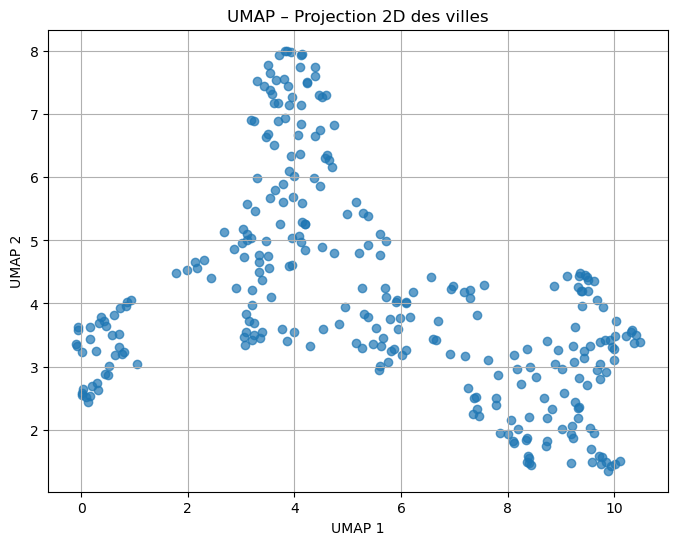

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP – Projection 2D des villes")
plt.grid(True)
plt.show()

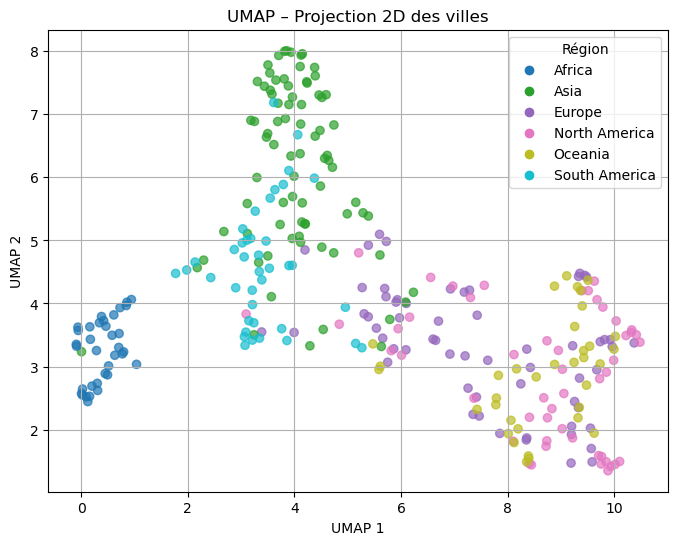

In [12]:
region = df['country']  # ou 'Europe', 'Asia', etc.

le = LabelEncoder()
region_codes = le.fit_transform(region)  # 0,1,2,...

colors = plt.cm.tab10(region_codes / max(region_codes))  # normalisation pour la colormap

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=colors, alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP – Projection 2D des villes")
plt.grid(True)

# Ajouter légende avec les noms de pays
handles = []
for i, label in enumerate(le.classes_):
    handles.append(plt.Line2D([], [], marker="o", linestyle="", color=plt.cm.tab10(i/max(region_codes)), label=label))
plt.legend(handles=handles, title="Région")

plt.show()

Le plot UMAP 2D montre que les villes se regroupent naturellement selon leur région géographique, indiquant que les caractéristiques socio-économiques et environnementales sont similaires au sein d’une même région. UMAP permet de visualiser ces similitudes dans un espace 2D tout en préservant les relations locales et globales entre villes. Les clusters distincts montrent aussi des différences notables entre régions, comme entre l’Afrique et l’Amérique du Nord.

In [8]:
# Création du DataFrame 2D
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

# Export en CSV
umap_df.to_csv("../outputs/umap_emb_2d.csv", index=False)